# 실습 — 이미지 분류 모델 파인튜닝 및 성능 평가 (12주차 1교시)

**학습 목표**
- 11주차에서 발견한 사전학습 모델의 한계를 **파인튜닝(전이학습)**으로 해결한다.
- HuggingFace `Trainer` API로 ViT를 **CIFAR-10**에 맞게 학습한다. (백본 동결 + 헤드만 학습 = 선형 탐침)
- **정확도·F1·혼동행렬**로 평가하고, 잘못 분류한 사례를 분석한다.
- 모델을 파일로 저장해 **2교시 Streamlit 웹 앱**을 준비한다.

**사전 조건**
```
pip install torch torchvision transformers accelerate datasets scikit-learn pillow matplotlib
```
> 강의실 환경: **GPU(8GB)**. CPU에서도 동작하지만 더 느립니다.
> 강의안: [`12_week/plane/1교시_이미지_분류_모델_파인튜닝_및_성능평가.md`](../../12_week/plane/1%EA%B5%90%EC%8B%9C_%EC%9D%B4%EB%AF%B8%EC%A7%80_%EB%B6%84%EB%A5%98_%EB%AA%A8%EB%8D%B8_%ED%8C%8C%EC%9D%B8%ED%8A%9C%EB%8B%9D_%EB%B0%8F_%EC%84%B1%EB%8A%A5%ED%8F%89%EA%B0%80.md)

## 셀 [0] — 한글 폰트 + 실행 장치 확인

matplotlib 한글 깨짐 방지 + GPU(8GB) 사용 여부를 확인합니다.

In [1]:
import platform
import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams

# matplotlib 한글 폰트
if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False

# 실행 장치 확인 (강의실: 8GB GPU)
USE_CUDA = torch.cuda.is_available()
print("PyTorch:", torch.__version__)
print("실행 장치:", torch.cuda.get_device_name(0) if USE_CUDA else "CPU")
if USE_CUDA:
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.12.0+cpu
실행 장치: CPU


## 셀 [1] — CIFAR-10 로드 + 라벨 매핑

11주차에 캐시됐으면 즉시 로드됩니다. 수업 시간 안에 끝내기 위해 **일부만** 사용합니다.

In [2]:
from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")   # 11주차에 캐시됨 → 즉시 로드

# ★ 수업 시간 안에 끝내기 위해 일부만 사용 (실무에선 전체 5만 장)
#   8GB GPU 기준 아래 정도면 몇 분 내 완료. 여유 있으면 숫자를 늘리세요.
train_ds = ds["train"].shuffle(seed=42).select(range(5000))
test_ds  = ds["test"].shuffle(seed=42).select(range(1000))

# 라벨 이름 <-> 숫자 매핑 (모델에 알려줄 사전)
labels   = ds["train"].features["label"].names
id2label = {i: name for i, name in enumerate(labels)}
label2id = {name: i for i, name in enumerate(labels)}

print("클래스:", labels)
print(f"학습 {len(train_ds)}장 / 평가 {len(test_ds)}장")

C:\Users\6-112\Desktop\pry\bigdata-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


클래스: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
학습 5000장 / 평가 1000장


## 셀 [2] — 전처리 (모델이 학습한 방식 그대로)

`ViTImageProcessor`에서 **입력 크기·정규화 통계**를 가져와 그대로 적용합니다.
(직접 적지 않는 이유: "이 모델이 학습할 때 쓴 값"을 그대로 써야 하기 때문)

In [3]:
from transformers import ViTImageProcessor
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

MODEL_NAME = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

# 모델이 학습할 때 쓴 입력 크기/정규화 통계를 그대로 사용
size = processor.size.get("height", processor.size.get("shortest_edge", 224))
normalize = Normalize(mean=processor.image_mean, std=processor.image_std)

_transform = Compose([
    Resize((size, size)),   # 32x32 -> 224x224
    ToTensor(),             # 0~255 -> 0~1, HWC -> CHW
    normalize,              # 사전학습 통계로 정규화
])

def transform(batch):
    # CIFAR-10의 이미지 컬럼명은 'img'
    batch["pixel_values"] = [_transform(img.convert("RGB")) for img in batch["img"]]
    return batch

train_ds.set_transform(transform)   # 꺼낼 때만 변환 (메모리 절약)
test_ds.set_transform(transform)

print("입력 크기:", size)
print("mean:", processor.image_mean, "/ std:", processor.image_std)

입력 크기: 224
mean: (0.5, 0.5, 0.5) / std: (0.5, 0.5, 0.5)


## 셀 [3] — 전처리 결과 확인

한 장을 꺼내 shape `(3, 224, 224)`를 확인하고, 역정규화해서 눈으로 봅니다.

pixel_values shape: (3, 224, 224)
정답 라벨: automobile


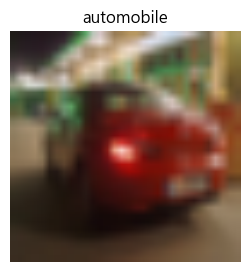

In [4]:
sample = train_ds[0]
print("pixel_values shape:", tuple(sample["pixel_values"].shape))   # (3, 224, 224)
print("정답 라벨:", labels[sample["label"]])

# 역정규화해서 사람 눈으로 확인
mean = torch.tensor(processor.image_mean).view(3, 1, 1)
std  = torch.tensor(processor.image_std).view(3, 1, 1)
vis  = (sample["pixel_values"] * std + mean).clamp(0, 1).permute(1, 2, 0)

plt.figure(figsize=(3, 3))
plt.imshow(vis)
plt.title(labels[sample["label"]])
plt.axis("off")
plt.show()

## 셀 [4] — 분류기 헤드를 10개로 교체

`ignore_mismatched_sizes=True` 덕분에 출력 1000 -> 10 으로 헤드를 갈아낍니다.
> "Some weights ... newly initialized" 경고가 뜨는데 **정상**입니다 (새 헤드는 백지 상태).

In [5]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=10,                  # 1000 -> 10
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,   # 헤드 크기가 달라졌으니 새로 초기화
)
print(model.classifier)   # Linear(in_features=768, out_features=10)

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|█| 200/200 [00:
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Linear(in_features=768, out_features=10, bias=True)


## 셀 [5] — 백본 동결 (빠른 학습의 핵심) ★

`classifier`를 제외한 모든 파라미터를 얼립니다. 학습 대상이 0.01%로 줄어 8GB GPU에서 1~2분이면 끝납니다.

In [6]:
# 분류기(classifier)를 제외한 모든 파라미터를 얼린다
for name, param in model.named_parameters():
    if not name.startswith("classifier"):
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"학습 대상: {trainable:,} / 전체: {total:,}  ({trainable / total * 100:.2f}%)")

학습 대상: 7,690 / 전체: 85,806,346  (0.01%)


## 셀 [6] — 배치 묶기 + 평가지표 함수

`collate_fn`은 여러 장을 배치 텐서로 묶고, `compute_metrics`는 정확도·F1을 계산합니다.

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def collate_fn(batch):
    pixel_values = torch.stack([x["pixel_values"] for x in batch])
    labels_t     = torch.tensor([x["label"] for x in batch])
    return {"pixel_values": pixel_values, "labels": labels_t}

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    refs  = eval_pred.label_ids
    return {
        "accuracy": accuracy_score(refs, preds),
        "f1_macro": f1_score(refs, preds, average="macro"),
    }

## 셀 [7] — 학습 설정 + Trainer 준비

`fp16`은 GPU일 때만 켜고, `remove_unused_columns=False`는 `set_transform`과 함께 쓸 때 필수입니다.
> 버전 호환: 신버전은 `eval_strategy`, 구버전은 `evaluation_strategy` — 아래에서 자동 선택합니다.

In [8]:
import inspect
from transformers import TrainingArguments, Trainer

# transformers 버전별 인자명 호환 (eval_strategy vs evaluation_strategy)
_params   = inspect.signature(TrainingArguments.__init__).parameters
_eval_key = "eval_strategy" if "eval_strategy" in _params else "evaluation_strategy"

args = TrainingArguments(
    output_dir="./vit-cifar10-ckpt",
    per_device_train_batch_size=16,   # 헤드만 학습 -> 8GB에서 16 OK (전체 미세조정은 8)
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    learning_rate=1e-3,               # 헤드만 학습 -> 조금 크게
    fp16=USE_CUDA,                    # 8GB GPU 가속 + 메모리 절약 (CPU면 자동 False)
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=20,
    remove_unused_columns=False,      # ★ set_transform 쓸 때 필수
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    **{_eval_key: "epoch"},           # 매 epoch마다 평가
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)
print("Trainer 준비 완료. (eval 인자명:", _eval_key, ")")

Trainer 준비 완료. (eval 인자명: eval_strategy )


## 셀 [8] — 학습 시작 ★

epoch가 지날수록 Loss는 내려가고 Accuracy는 올라갑니다. (8GB GPU·5000장·3epoch ≈ 2~4분)

In [9]:
trainer.train()

C:\Users\6-112\Desktop\pry\bigdata-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.165906,0.128821,0.958000,0.956443
2,0.082600,0.115622,0.959000,0.957414
3,0.056323,0.112746,0.960000,0.958235


Writing model shards: 100%|█| 1/1 [00
C:\Users\6-112\Desktop\pry\bigdata-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|█| 1/1 [00
C:\Users\6-112\Desktop\pry\bigdata-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|█| 1/1 [00
[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'v

TrainOutput(global_step=939, training_loss=0.12049976756143621, metrics={'train_runtime': 1819.0554, 'train_samples_per_second': 8.246, 'train_steps_per_second': 0.516, 'total_flos': 1.16246318856192e+18, 'train_loss': 0.12049976756143621, 'epoch': 3.0})

## 셀 [9] — 최종 성능 (정확도 · F1)

11주차에 그대로 적용했을 땐 40~60%였는데, 헤드만 학습해도 85% 안팎으로 뜁니다.

In [10]:
metrics = trainer.evaluate()
print(f"정확도(Accuracy): {metrics['eval_accuracy'] * 100:.1f}%")
print(f"F1 (macro)      : {metrics['eval_f1_macro'] * 100:.1f}%")

C:\Users\6-112\Desktop\pry\bigdata-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.056323,0.112746,3,0.960000,0.958235


정확도(Accuracy): 96.0%
F1 (macro)      : 95.8%


## 셀 [10] — 혼동행렬 (무엇을 무엇으로 헷갈렸나)

대각선이 진할수록 잘 맞춘 것. cat<->dog, automobile<->truck 처럼 사람도 헷갈리는 쌍을 확인하세요.

C:\Users\6-112\Desktop\pry\bigdata-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


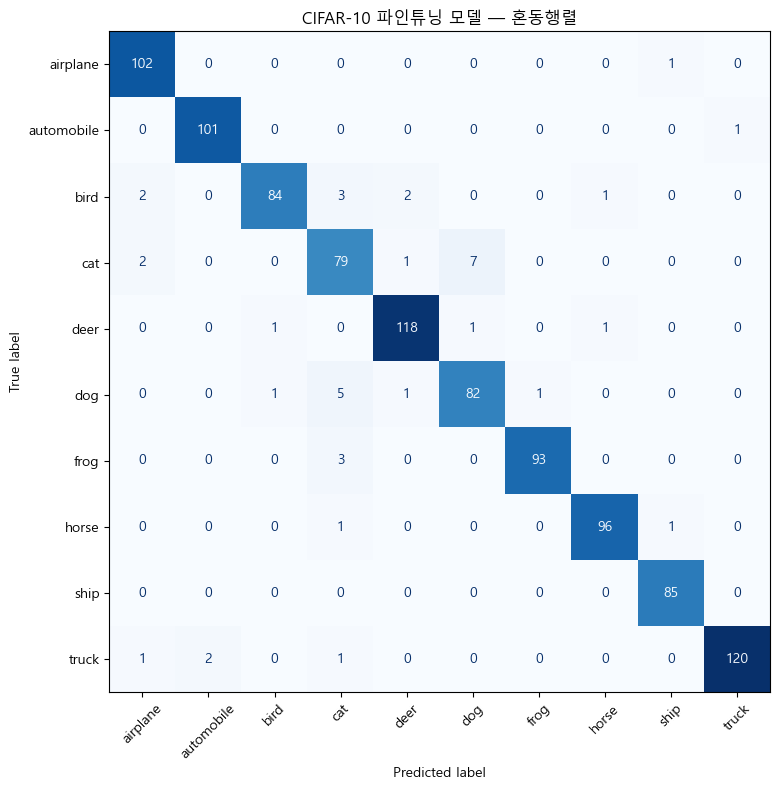

              precision    recall  f1-score   support

    airplane       0.95      0.99      0.97       103
  automobile       0.98      0.99      0.99       102
        bird       0.98      0.91      0.94        92
         cat       0.86      0.89      0.87        89
        deer       0.97      0.98      0.97       121
         dog       0.91      0.91      0.91        90
        frog       0.99      0.97      0.98        96
       horse       0.98      0.98      0.98        98
        ship       0.98      1.00      0.99        85
       truck       0.99      0.97      0.98       124

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False
)
ax.set_title("CIFAR-10 파인튜닝 모델 — 혼동행렬")
plt.tight_layout()
plt.show()

# (참고) 클래스별 상세 리포트
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=labels))

## 셀 [11] — 오분류 사례 직접 보기

틀린 사진을 눈으로 보며 "나라면 맞췄을까?"를 토론합니다. 흐릿한 32x32는 사람도 헷갈립니다.

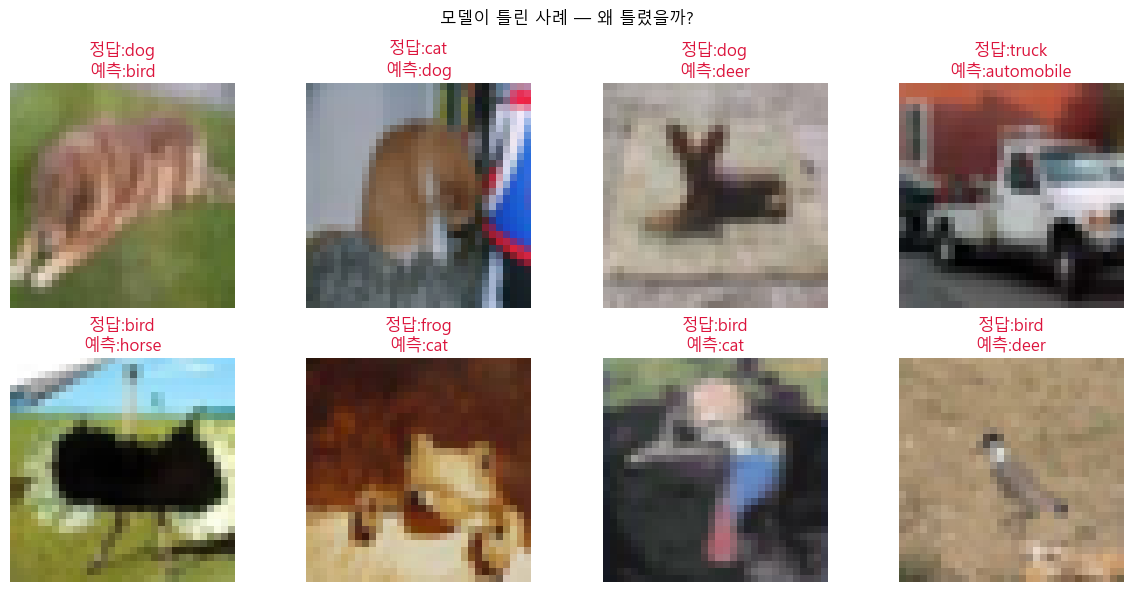

In [12]:
wrong_idx = np.where(y_pred != y_true)[0][:8]

if len(wrong_idx) == 0:
    print("틀린 사례가 없습니다! (데이터를 늘려 다시 시도해보세요)")
else:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, i in zip(axes.ravel(), wrong_idx):
        ax.imshow(test_ds[int(i)]["img"])
        ax.set_title(f"정답:{labels[y_true[i]]}\n예측:{labels[y_pred[i]]}", color="crimson")
        ax.axis("off")
    for ax in axes.ravel()[len(wrong_idx):]:   # 남는 칸 숨기기
        ax.axis("off")
    plt.suptitle("모델이 틀린 사례 — 왜 틀렸을까?")
    plt.tight_layout()
    plt.show()

## 셀 [12] — 모델 저장 (2교시 웹 앱 준비) ★

모델과 `processor`를 **같은 폴더**에 저장해야 2교시에서 `pipeline` 한 줄로 불러올 수 있습니다.

In [13]:
import os

SAVE_DIR = "./vit-cifar10-finetuned"
trainer.save_model(SAVE_DIR)         # 모델 가중치 + 설정
processor.save_pretrained(SAVE_DIR)  # 전처리 설정도 함께 (★ 중요)

print("✅ 저장 완료:", os.path.abspath(SAVE_DIR))
print("폴더 내용:", os.listdir(SAVE_DIR))

Writing model shards: 100%|█| 1/1 [00

✅ 저장 완료: C:\Users\6-112\Desktop\pry\bigdata-project\12_week\vit-cifar10-finetuned
폴더 내용: ['config.json', 'model.safetensors', 'preprocessor_config.json', 'training_args.bin']


---
## 1교시 마무리 체크리스트

- [ ] 셀 [5]에서 학습 대상 파라미터가 전체의 약 0.01%로 줄었다.
- [ ] 셀 [8] 학습에서 Accuracy가 epoch마다 올라갔다.
- [ ] 셀 [9]에서 정확도가 80%대 이상으로 나왔다.
- [ ] 셀 [10] 혼동행렬에서 자주 헷갈리는 클래스 쌍을 찾았다.
- [ ] 셀 [12]에서 `vit-cifar10-finetuned/` 폴더가 생성됐다.

**2교시 예고**: 방금 저장한 모델을 **Streamlit 웹 앱**(`app.py`)으로 배포해,
이미지를 업로드하거나 카메라로 찍으면 즉시 분류되게 만듭니다.